# OSL Dataset Analysis
Comprehensive analysis of the Omani Sign Language (OSL) dataset.

**Dataset Categories:**
- Letters
- Numbers
- Words
- Sentences

## 1. Setup and Imports

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from pathlib import Path
from collections import Counter
from datetime import datetime

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

# Base paths
BASE_PATH = Path('..')
DATA_PATH = BASE_PATH / 'data'
DATASET_PATH = BASE_PATH / 'dataset'

print('Setup complete!')
print(f'Working directory: {os.getcwd()}')

Setup complete!
Working directory: c:\Users\MOBPC\Downloads\FYP\Dataset


## 2. Load Label Mappings
Load word and sentence definitions from text files.

In [26]:
def load_labels(filepath):
    """Load ID to text mapping from labels file"""
    mapping = {}
    if not Path(filepath).exists():
        print(f'File not found: {filepath}')
        return mapping
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(' ', 1)
            if len(parts) == 2:
                try:
                    # Handle IDs with letter prefix (e.g., N0000, L0001)
                    id_part = parts[0]
                    if id_part[0].isalpha():
                        mapping[int(id_part[1:])] = parts[1]
                    else:
                        mapping[int(id_part)] = parts[1]
                except ValueError:
                    pass
    return mapping

# Load all label mappings
labels = {
    'Words': load_labels('../Words.txt'),
    'Sentences': load_labels('../Sentences.txt'),
    'Letters': load_labels('../Letters.txt'),
    'Numbers': load_labels('../Numbers.txt')
}

print('Label Mappings Loaded:')
print('-' * 40)
for category, mapping in labels.items():
    print(f'  {category}: {len(mapping)} items')

Label Mappings Loaded:
----------------------------------------
  Words: 800 items
  Sentences: 444 items
  Letters: 28 items
  Numbers: 11 items


## 3. Scan Video Files
Scan all video files in dataset folders and extract metadata.

In [27]:
def get_video_info(video_path):
    """Extract video metadata using OpenCV"""
    try:
        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            return None
        info = {
            'fps': round(cap.get(cv2.CAP_PROP_FPS), 2),
            'frame_count': int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
            'width': int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
            'height': int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
        }
        info['duration_sec'] = round(info['frame_count'] / info['fps'], 2) if info['fps'] > 0 else 0
        cap.release()
        return info
    except Exception as e:
        return None

def scan_videos(category):
    """Scan all videos in a category folder"""
    folder = DATASET_PATH / f'OSL-{category}' / 'rgb_format'
    if not folder.exists():
        print(f'Folder not found: {folder}')
        return pd.DataFrame()
    
    videos = list(folder.glob('*.mp4'))
    data = []
    
    print(f'Scanning {category}: {len(videos)} videos...')
    
    for i, video in enumerate(videos):
        if i % 200 == 0 and i > 0:
            print(f'  Progress: {i}/{len(videos)}')
        
        parts = video.stem.split('_')
        try:
            # Handle IDs with letter prefix (e.g., N0000, L0001)
            id_part = parts[0]
            if id_part[0].isalpha():
                item_id = int(id_part[1:])
            else:
                item_id = int(id_part)
        except:
            continue
        
        speaker = parts[1] if len(parts) > 1 else ''
        take = parts[2] if len(parts) > 2 else ''
        
        # Get label text
        label_text = labels.get(category, {}).get(item_id, '')
        
        # Get video info
        info = get_video_info(video)
        
        record = {
            'video_id': video.stem,
            'item_id': item_id,
            'label': label_text,
            'speaker': speaker,
            'take': take,
            'filename': video.name,
            'path': str(video),
        }
        
        if info:
            record.update(info)
        
        data.append(record)
    
    df = pd.DataFrame(data)
    if len(df) > 0:
        df = df.sort_values(['item_id', 'speaker', 'take']).reset_index(drop=True)
    
    print(f'  Done: {len(df)} videos processed')
    return df

# Scan all categories
video_data = {}
for category in ['Words', 'Sentences', 'Numbers', 'Letters']:
    video_data[category] = scan_videos(category)

print('\n' + '=' * 50)
print('Video Scanning Complete!')
print('=' * 50)

Scanning Words: 1235 videos...
  Progress: 200/1235
  Progress: 400/1235
  Progress: 600/1235
  Progress: 800/1235
  Progress: 1000/1235
  Progress: 1200/1235
  Done: 1235 videos processed
Scanning Sentences: 447 videos...
  Progress: 200/447
  Progress: 400/447
  Done: 447 videos processed
Scanning Numbers: 22 videos...
  Done: 22 videos processed
Scanning Letters: 0 videos...
  Done: 0 videos processed

Video Scanning Complete!


## 4. Update Metadata Files
Generate and save updated metadata CSV files with proper Arabic encoding.

In [40]:
def dataframes_equal(df1, df2):
    """Check if two dataframes have the same content (ignoring index)"""
    if df1 is None or df2 is None:
        return False
    if df1.shape != df2.shape:
        return False
    if list(df1.columns) != list(df2.columns):
        return False
    # Compare values
    try:
        return df1.reset_index(drop=True).equals(df2.reset_index(drop=True))
    except:
        return False

# Update metadata files for each category (only if changed)
for category, df in video_data.items():
    if len(df) == 0:
        print(f'{category}: No data to save')
        continue
    
    # Ensure output directory exists
    output_dir = DATA_PATH / f'OSL-{category}'
    output_dir.mkdir(parents=True, exist_ok=True)
    
    csv_path = output_dir / 'metadata.csv'
    xlsx_path = output_dir / 'metadata.xlsx'
    
    # Check if CSV exists and compare
    needs_update = True
    if csv_path.exists():
        try:
            existing_df = pd.read_csv(csv_path, encoding='utf-8-sig')
            if dataframes_equal(existing_df, df):
                needs_update = False
                print(f'{category}: No changes detected - skipping')
        except Exception as e:
            print(f'{category}: Could not read existing file, will recreate')
    
    if needs_update:
        # Save CSV with UTF-8 BOM for Excel compatibility
        df.to_csv(csv_path, index=False, encoding='utf-8-sig')
        
        # Save Excel file for better Arabic support
        try:
            df.to_excel(xlsx_path, index=False, engine='openpyxl')
            print(f'{category}: Updated {len(df)} records')
            print(f'  - {csv_path}')
            print(f'  - {xlsx_path}')
        except Exception as e:
            print(f'{category}: Saved CSV only (Excel error: {e})')
            print(f'  - {csv_path}')



Words: Updated 1235 records
  - data\OSL-Words\metadata.csv
  - data\OSL-Words\metadata.xlsx
Sentences: Updated 447 records
  - data\OSL-Sentences\metadata.csv
  - data\OSL-Sentences\metadata.xlsx
Numbers: Updated 22 records
  - data\OSL-Numbers\metadata.csv
  - data\OSL-Numbers\metadata.xlsx
Letters: No data to save


## 5. Dataset Overview

In [30]:
# Create summary statistics
summary_data = []

for category, df in video_data.items():
    if len(df) == 0:
        continue
    
    total_labels = len(labels.get(category, {}))
    recorded_ids = df['item_id'].nunique()
    
    summary_data.append({
        'Category': category,
        'Total Videos': len(df),
        'Unique IDs': recorded_ids,
        'Total Labels': total_labels,
        'Coverage %': round(recorded_ids / total_labels * 100, 1) if total_labels > 0 else 0,
        'Missing': total_labels - recorded_ids if total_labels > 0 else 0,
        'Speakers': df['speaker'].nunique(),
        'Total Duration (min)': round(df['duration_sec'].sum() / 60, 1) if 'duration_sec' in df else 0,
        'Avg Duration (sec)': round(df['duration_sec'].mean(), 2) if 'duration_sec' in df else 0
    })

summary_df = pd.DataFrame(summary_data)
print('=' * 70)
print('DATASET OVERVIEW')
print('=' * 70)
display(summary_df)

# Totals
print('\n' + '-' * 50)
print(f"Total Videos: {summary_df['Total Videos'].sum():,}")
print(f"Total Duration: {summary_df['Total Duration (min)'].sum():.1f} minutes ({summary_df['Total Duration (min)'].sum()/60:.2f} hours)")

DATASET OVERVIEW


,Category,Total Videos,Unique IDs,Total Labels,Coverage %,Missing,Speakers,Total Duration (min),Avg Duration (sec)
0,Words,1235,692,800,86.5,108,8,49.0,2.38
1,Sentences,447,419,444,94.4,25,8,32.7,4.39
2,Numbers,22,11,11,100.0,0,1,1.4,3.93



--------------------------------------------------
Total Videos: 1,704
Total Duration: 83.1 minutes (1.39 hours)


## 6. Recording Progress Visualization

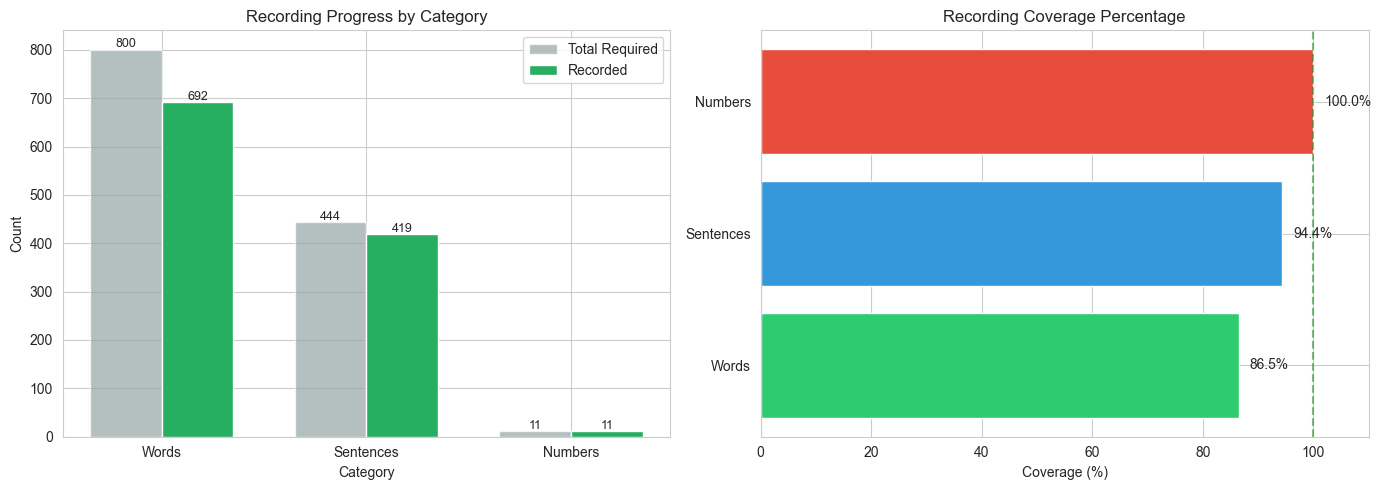

In [31]:
# Coverage bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

categories = summary_df['Category'].tolist()
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

# Video count comparison
ax1 = axes[0]
x = np.arange(len(categories))
width = 0.35

recorded = summary_df['Unique IDs'].tolist()
total = summary_df['Total Labels'].tolist()

bars1 = ax1.bar(x - width/2, total, width, label='Total Required', color='#95a5a6', alpha=0.7)
bars2 = ax1.bar(x + width/2, recorded, width, label='Recorded', color='#27ae60')

ax1.set_xlabel('Category')
ax1.set_ylabel('Count')
ax1.set_title('Recording Progress by Category')
ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.legend()

for bar, val in zip(bars1, total):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val), ha='center', fontsize=9)
for bar, val in zip(bars2, recorded):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val), ha='center', fontsize=9)

# Coverage percentage
ax2 = axes[1]
coverage = summary_df['Coverage %'].tolist()
bars = ax2.barh(categories, coverage, color=colors)
ax2.set_xlabel('Coverage (%)')
ax2.set_title('Recording Coverage Percentage')
ax2.set_xlim(0, 110)
ax2.axvline(x=100, color='green', linestyle='--', alpha=0.5, label='100% Target')

for bar, val in zip(bars, coverage):
    ax2.text(val + 2, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 7. Missing Items Analysis

In [32]:
# Find missing items for each category
missing_items = {}

for category in ['Words', 'Sentences']:
    df = video_data.get(category, pd.DataFrame())
    all_ids = set(labels.get(category, {}).keys())
    recorded_ids = set(df['item_id'].unique()) if len(df) > 0 else set()
    missing_ids = sorted(all_ids - recorded_ids)
    
    missing_items[category] = [
        {'id': mid, 'label': labels[category].get(mid, '')} 
        for mid in missing_ids
    ]
    
    print('=' * 60)
    print(f'MISSING {category.upper()}: {len(missing_ids)} items')
    print('=' * 60)
    
    if len(missing_ids) == 0:
        print('All items have been recorded!')
    else:
        missing_df = pd.DataFrame(missing_items[category])
        display(missing_df)
        
        # Check if file exists and compare before saving
        output_dir = DATA_PATH / f'OSL-{category}'
        output_dir.mkdir(parents=True, exist_ok=True)
        
        csv_path = output_dir / 'missing_items.csv'
        xlsx_path = output_dir / 'missing_items.xlsx'
        
        needs_update = True
        if csv_path.exists():
            try:
                existing_df = pd.read_csv(csv_path, encoding='utf-8-sig')
                if dataframes_equal(existing_df, missing_df):
                    needs_update = False
                    print(f'No changes in missing items - skipping save')
            except:
                pass
        
        if needs_update:
            missing_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
            try:
                missing_df.to_excel(xlsx_path, index=False, engine='openpyxl')
            except:
                pass
            print(f'Updated: {csv_path}')
    
    print()

MISSING WORDS: 109 items


,id,label
0,134,إشارة
1,160,قريباً
2,208,آمن
3,240,بطارية
4,241,شحن
...,...,...
104,417,بمناسبة
105,419,للتدريب
106,420,متخصص
107,448,أنتِ


No changes in missing items - skipping save

MISSING SENTENCES: 25 items


,id,label
0,111,هذا صديقي المقرب
1,207,راجعت البلدية اليوم
2,212,وقفت في الموقف
3,224,هذه وجهتي اليوم
4,307,لغة انجليزية
5,308,لغة عربية
6,309,يوم التمريض الخليجي
7,310,ورشة عمل
8,311,وين بالضبط
9,312,لذوي الإعاقة السمعية


No changes in missing items - skipping save



## 8. Speaker Distribution Analysis

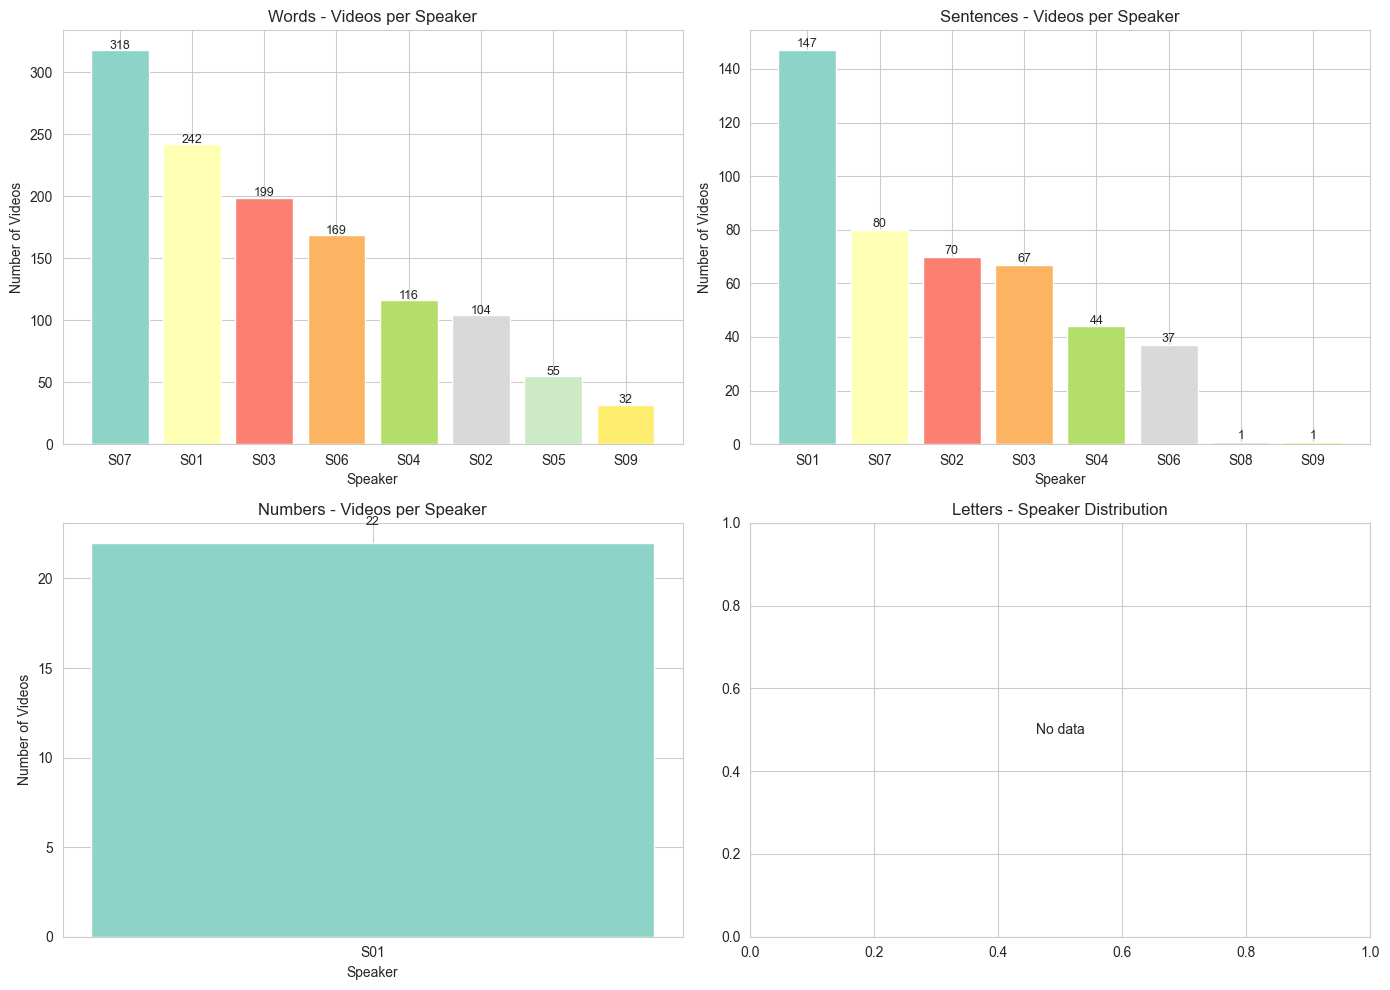


Speaker Summary:
--------------------------------------------------
Words: 8 speakers - {'S07': 318, 'S01': 242, 'S03': 199, 'S06': 169, 'S04': 116, 'S02': 104, 'S05': 55, 'S09': 32}
Sentences: 8 speakers - {'S01': 147, 'S07': 80, 'S02': 70, 'S03': 67, 'S04': 44, 'S06': 37, 'S08': 1, 'S09': 1}
Numbers: 1 speakers - {'S01': 22}


In [33]:
# Analyze speaker distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, category in enumerate(['Words', 'Sentences', 'Numbers', 'Letters']):
    df = video_data.get(category, pd.DataFrame())
    ax = axes[i]
    
    if len(df) == 0 or 'speaker' not in df.columns:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{category} - Speaker Distribution')
        continue
    
    speaker_counts = df['speaker'].value_counts()
    
    if len(speaker_counts) > 0:
        bars = ax.bar(speaker_counts.index, speaker_counts.values, color=plt.cm.Set3(np.linspace(0, 1, len(speaker_counts))))
        ax.set_xlabel('Speaker')
        ax.set_ylabel('Number of Videos')
        ax.set_title(f'{category} - Videos per Speaker')
        
        for bar, val in zip(bars, speaker_counts.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Speaker summary table
print('\nSpeaker Summary:')
print('-' * 50)
for category, df in video_data.items():
    if len(df) > 0 and 'speaker' in df.columns:
        speakers = df['speaker'].value_counts()
        print(f'{category}: {len(speakers)} speakers - {dict(speakers)}')

## 9. Video Duration Analysis

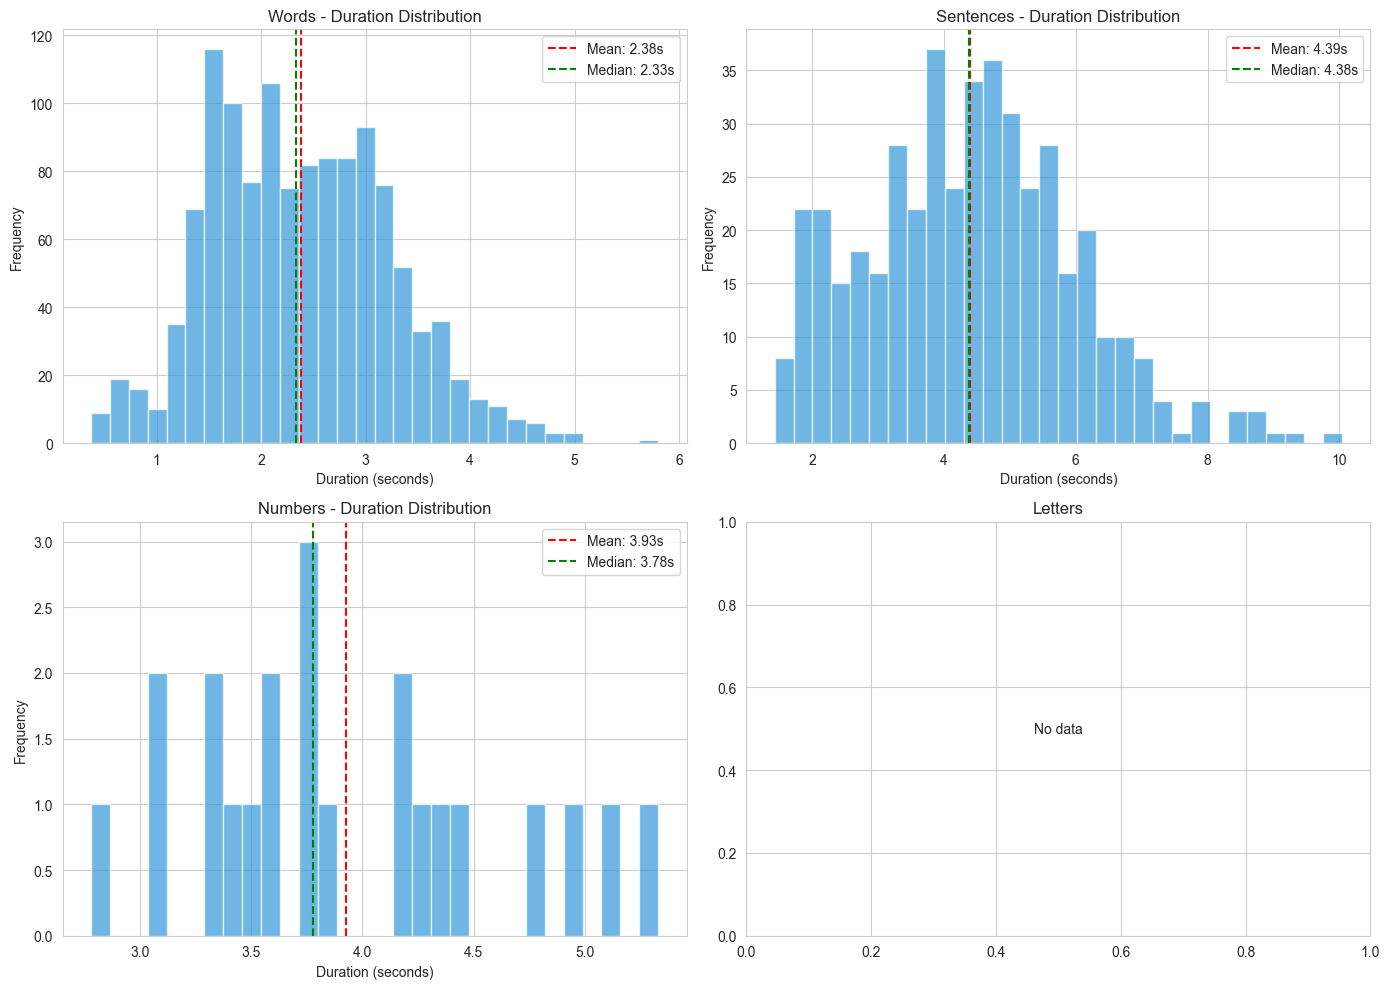


Duration Statistics:
------------------------------------------------------------
Words:
  Min: 0.37s | Max: 5.80s | Mean: 2.38s | Std: 0.86s
  Total: 49.0 min
Sentences:
  Min: 1.43s | Max: 10.04s | Mean: 4.39s | Std: 1.58s
  Total: 32.7 min
Numbers:
  Min: 2.78s | Max: 5.33s | Mean: 3.93s | Std: 0.69s
  Total: 1.4 min


In [34]:
# Duration distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, category in enumerate(['Words', 'Sentences', 'Numbers', 'Letters']):
    df = video_data.get(category, pd.DataFrame())
    ax = axes[i]
    
    if len(df) == 0 or 'duration_sec' not in df.columns:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{category}')
        continue
    
    durations = df['duration_sec'].dropna()
    
    if len(durations) > 0:
        ax.hist(durations, bins=30, color='#3498db', edgecolor='white', alpha=0.7)
        ax.axvline(durations.mean(), color='red', linestyle='--', label=f'Mean: {durations.mean():.2f}s')
        ax.axvline(durations.median(), color='green', linestyle='--', label=f'Median: {durations.median():.2f}s')
        ax.set_xlabel('Duration (seconds)')
        ax.set_ylabel('Frequency')
        ax.set_title(f'{category} - Duration Distribution')
        ax.legend()

plt.tight_layout()
plt.show()

# Duration statistics
print('\nDuration Statistics:')
print('-' * 60)
for category, df in video_data.items():
    if len(df) > 0 and 'duration_sec' in df.columns:
        d = df['duration_sec']
        print(f'{category}:')
        print(f'  Min: {d.min():.2f}s | Max: {d.max():.2f}s | Mean: {d.mean():.2f}s | Std: {d.std():.2f}s')
        print(f'  Total: {d.sum()/60:.1f} min')

## 10. Video Quality Analysis

In [35]:
# Analyze video quality (resolution, fps)
print('VIDEO QUALITY SUMMARY')
print('=' * 60)

for category, df in video_data.items():
    if len(df) == 0:
        continue
    
    print(f'\n{category}:')
    print('-' * 40)
    
    if 'width' in df.columns and 'height' in df.columns:
        # Resolution distribution
        df['resolution'] = df['width'].astype(str) + 'x' + df['height'].astype(str)
        res_counts = df['resolution'].value_counts()
        print(f'  Resolutions: {dict(res_counts)}')
    
    if 'fps' in df.columns:
        fps_counts = df['fps'].value_counts()
        print(f'  FPS values: {dict(fps_counts)}')
    
    if 'frame_count' in df.columns:
        fc = df['frame_count']
        print(f'  Frame count: Min={fc.min()}, Max={fc.max()}, Mean={fc.mean():.0f}')

VIDEO QUALITY SUMMARY

Words:
----------------------------------------
  Resolutions: {'1920x1080': 1199, '3840x2160': 36}
  FPS values: {30.0: 642, 16.4: 8, 16.32: 7, 16.63: 7, 16.2: 6, 16.25: 6, 16.37: 6, 25.1: 6, 25.02: 5, 16.22: 5, 16.48: 5, 16.18: 5, 16.08: 5, 25.21: 5, 25.01: 5, 25.22: 5, 16.28: 5, 25.18: 4, 16.05: 4, 16.26: 4, 25.23: 4, 16.43: 4, 16.27: 4, 16.14: 4, 24.96: 4, 25.09: 4, 16.44: 4, 16.46: 4, 16.38: 4, 25.17: 4, 25.0: 4, 25.2: 4, 29.57: 4, 24.46: 4, 25.16: 4, 16.23: 4, 16.41: 4, 24.75: 4, 16.34: 4, 24.92: 4, 16.5: 3, 24.32: 3, 15.79: 3, 16.17: 3, 25.36: 3, 16.29: 3, 24.93: 3, 29.76: 3, 16.19: 3, 24.85: 3, 30.8: 3, 23.98: 3, 25.39: 3, 25.37: 3, 24.49: 3, 16.07: 3, 24.61: 3, 25.28: 3, 16.81: 3, 25.19: 3, 16.45: 3, 24.6: 3, 24.23: 3, 16.39: 3, 16.54: 3, 16.42: 3, 29.68: 3, 24.15: 3, 29.89: 3, 25.14: 3, 29.7: 3, 25.07: 3, 25.32: 2, 30.63: 2, 30.53: 2, 25.15: 2, 29.97: 2, 17.01: 2, 24.94: 2, 24.98: 2, 25.47: 2, 16.49: 2, 16.1: 2, 16.86: 2, 16.75: 2, 15.84: 2, 16.88: 2, 1

## 11. Final Summary Report

In [36]:
# Generate final summary
print('=' * 70)
print('OSL DATASET ANALYSIS REPORT')
print(f'Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print('=' * 70)

total_videos = sum(len(df) for df in video_data.values())
total_duration = sum(df['duration_sec'].sum() if 'duration_sec' in df.columns else 0 for df in video_data.values())

print(f'\nTOTAL DATASET:')
print(f'  Videos: {total_videos:,}')
print(f'  Duration: {total_duration/60:.1f} minutes ({total_duration/3600:.2f} hours)')

print(f'\nBY CATEGORY:')
for category, df in video_data.items():
    if len(df) == 0:
        continue
    
    total_labels = len(labels.get(category, {}))
    recorded = df['item_id'].nunique()
    missing = total_labels - recorded
    coverage = (recorded / total_labels * 100) if total_labels > 0 else 0
    duration = df['duration_sec'].sum() if 'duration_sec' in df.columns else 0
    
    print(f'\n  {category}:')
    print(f'    Videos: {len(df)}')
    print(f'    Unique IDs: {recorded} / {total_labels} ({coverage:.1f}%)')
    print(f'    Missing: {missing}')
    print(f'    Duration: {duration/60:.1f} min')
    print(f'    Speakers: {df["speaker"].nunique() if "speaker" in df.columns else 0}')

print('\n' + '=' * 70)
print('Analysis Complete!')
print('=' * 70)

OSL DATASET ANALYSIS REPORT
Generated: 2026-03-04 08:39:05

TOTAL DATASET:
  Videos: 1,704
  Duration: 83.1 minutes (1.39 hours)

BY CATEGORY:

  Words:
    Videos: 1235
    Unique IDs: 692 / 800 (86.5%)
    Missing: 108
    Duration: 49.0 min
    Speakers: 8

  Sentences:
    Videos: 447
    Unique IDs: 419 / 444 (94.4%)
    Missing: 25
    Duration: 32.7 min
    Speakers: 8

  Numbers:
    Videos: 22
    Unique IDs: 11 / 11 (100.0%)
    Missing: 0
    Duration: 1.4 min
    Speakers: 1

Analysis Complete!


## 12. Statistical Features Analysis - Video Length Histograms

C:\Users\MOBPC\AppData\Local\Temp\ipykernel_21792\436493073.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax_combined1.boxplot(duration_data, labels=duration_labels, patch_artist=True)
C:\Users\MOBPC\AppData\Local\Temp\ipykernel_21792\436493073.py:100: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax_combined2.boxplot(frame_data, labels=frame_labels, patch_artist=True)


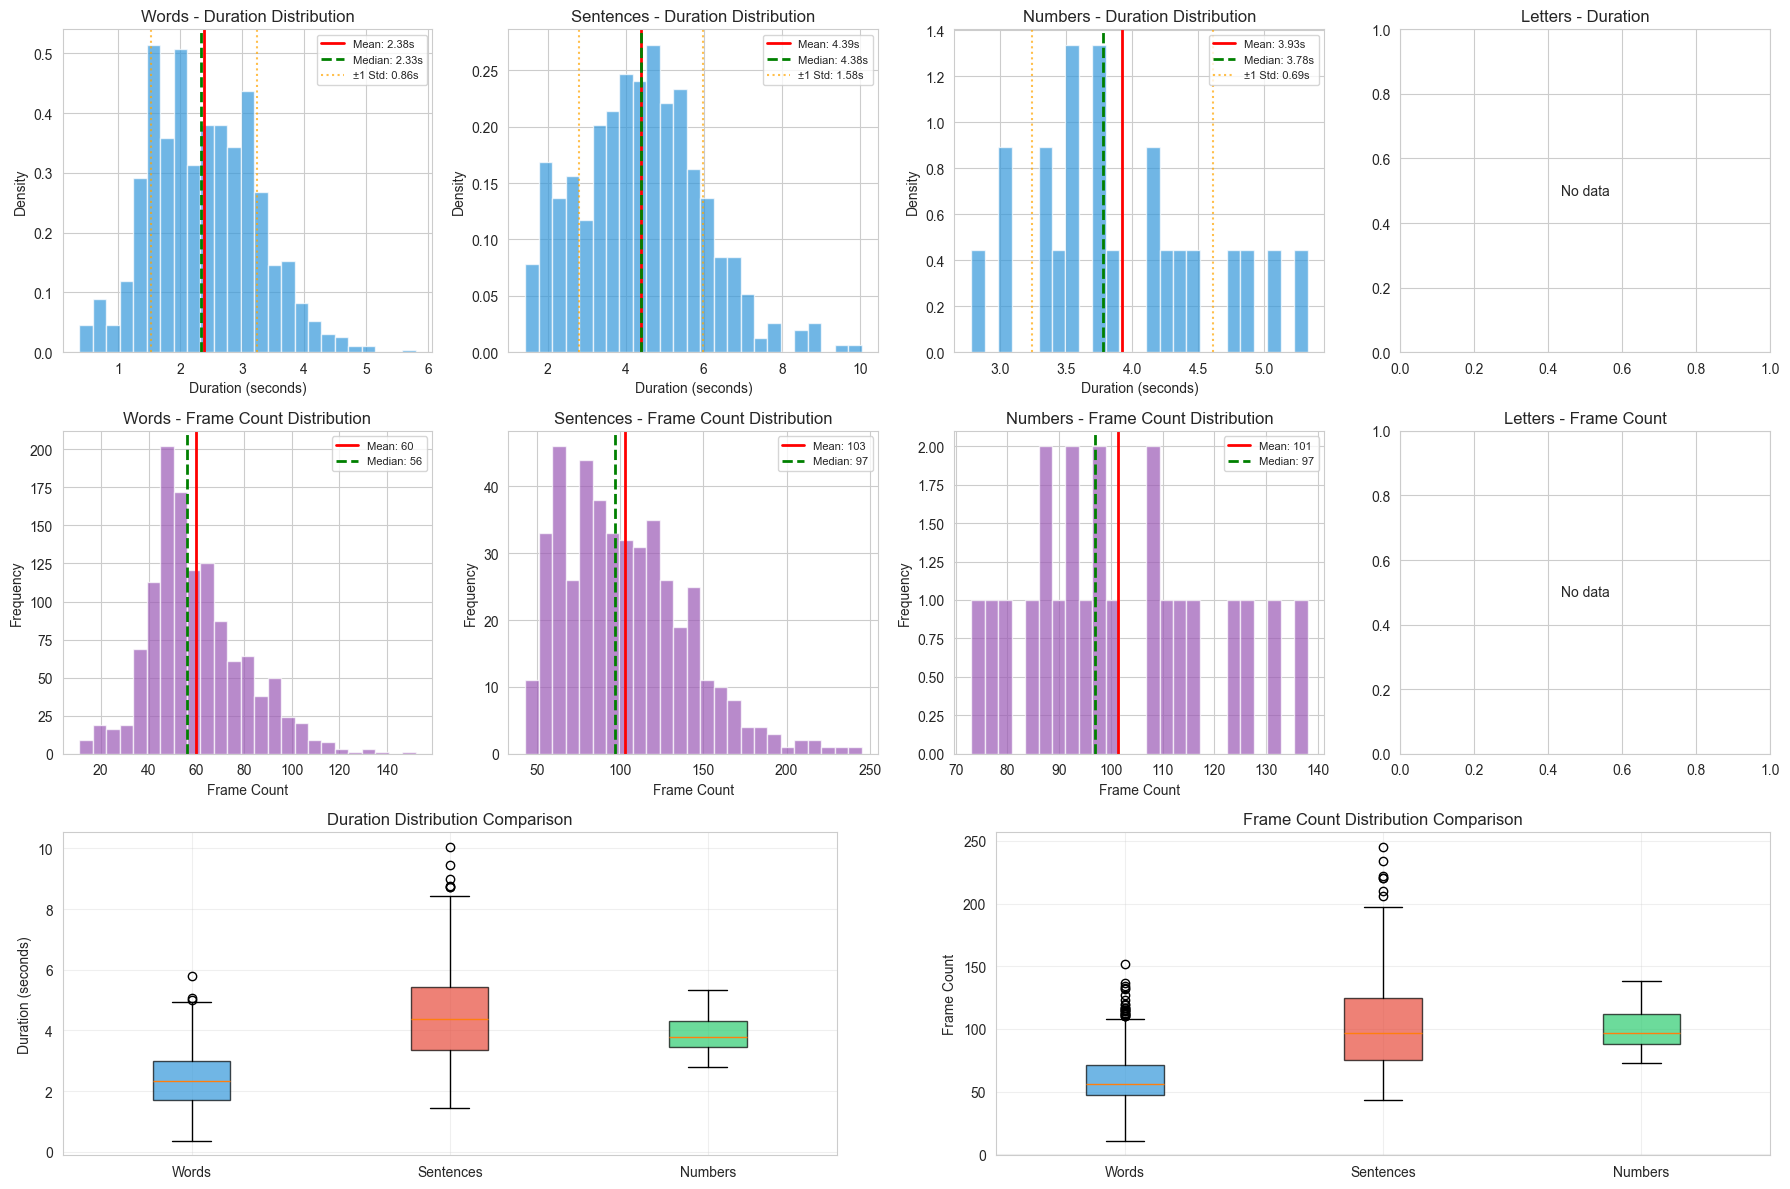


DETAILED VIDEO LENGTH STATISTICS


,Category,Count,Duration Min (s),Duration Max (s),Duration Mean (s),Duration Median (s),Duration Std (s),Duration Q1 (s),Duration Q3 (s),Frames Mean,Frames Std
0,Words,1235,0.37,5.80,2.38,2.33,0.86,1.70,3.00,60.0,20.0
1,Sentences,447,1.43,10.04,4.39,4.38,1.58,3.36,5.42,103.0,37.0
2,Numbers,22,2.78,5.33,3.93,3.78,0.69,3.44,4.31,101.0,18.0


In [37]:
# Statistical Analysis of Video Lengths
# Comprehensive histograms and statistics for video durations and frame counts

fig, axes = plt.subplots(3, 4, figsize=(18, 12))

categories = ['Words', 'Sentences', 'Numbers', 'Letters']

# Row 1: Duration histograms with detailed statistics
for i, category in enumerate(categories):
    df = video_data.get(category, pd.DataFrame())
    ax = axes[0, i]
    
    if len(df) == 0 or 'duration_sec' not in df.columns:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{category} - Duration')
        continue
    
    durations = df['duration_sec'].dropna()
    
    # Histogram with KDE
    ax.hist(durations, bins=25, density=True, alpha=0.7, color='#3498db', edgecolor='white')
    
    # Add statistics lines
    mean_val = durations.mean()
    median_val = durations.median()
    std_val = durations.std()
    
    ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.2f}s')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}s')
    ax.axvline(mean_val - std_val, color='orange', linestyle=':', alpha=0.7)
    ax.axvline(mean_val + std_val, color='orange', linestyle=':', alpha=0.7, label=f'±1 Std: {std_val:.2f}s')
    
    ax.set_xlabel('Duration (seconds)')
    ax.set_ylabel('Density')
    ax.set_title(f'{category} - Duration Distribution')
    ax.legend(fontsize=8)

# Row 2: Frame count histograms
for i, category in enumerate(categories):
    df = video_data.get(category, pd.DataFrame())
    ax = axes[1, i]
    
    if len(df) == 0 or 'frame_count' not in df.columns:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{category} - Frame Count')
        continue
    
    frames = df['frame_count'].dropna()
    
    ax.hist(frames, bins=25, alpha=0.7, color='#9b59b6', edgecolor='white')
    ax.axvline(frames.mean(), color='red', linestyle='-', linewidth=2, label=f'Mean: {frames.mean():.0f}')
    ax.axvline(frames.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {frames.median():.0f}')
    
    ax.set_xlabel('Frame Count')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{category} - Frame Count Distribution')
    ax.legend(fontsize=8)

# Row 3: Box plots comparing all categories
ax_box_duration = axes[2, 0:2]
ax_box_frames = axes[2, 2:4]

# Combined ax for duration boxplot
ax_combined1 = fig.add_subplot(3, 2, 5)
ax_combined2 = fig.add_subplot(3, 2, 6)

# Hide the original small axes
for ax in axes[2, :]:
    ax.set_visible(False)

# Duration boxplot
duration_data = []
duration_labels = []
for category in categories:
    df = video_data.get(category, pd.DataFrame())
    if len(df) > 0 and 'duration_sec' in df.columns:
        duration_data.append(df['duration_sec'].dropna().values)
        duration_labels.append(category)

if duration_data:
    bp1 = ax_combined1.boxplot(duration_data, labels=duration_labels, patch_artist=True)
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
    for patch, color in zip(bp1['boxes'], colors[:len(bp1['boxes'])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax_combined1.set_ylabel('Duration (seconds)')
    ax_combined1.set_title('Duration Distribution Comparison')
    ax_combined1.grid(True, alpha=0.3)

# Frame count boxplot
frame_data = []
frame_labels = []
for category in categories:
    df = video_data.get(category, pd.DataFrame())
    if len(df) > 0 and 'frame_count' in df.columns:
        frame_data.append(df['frame_count'].dropna().values)
        frame_labels.append(category)

if frame_data:
    bp2 = ax_combined2.boxplot(frame_data, labels=frame_labels, patch_artist=True)
    for patch, color in zip(bp2['boxes'], colors[:len(bp2['boxes'])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax_combined2.set_ylabel('Frame Count')
    ax_combined2.set_title('Frame Count Distribution Comparison')
    ax_combined2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Detailed Statistics Table
print('\n' + '=' * 80)
print('DETAILED VIDEO LENGTH STATISTICS')
print('=' * 80)

stats_data = []
for category in categories:
    df = video_data.get(category, pd.DataFrame())
    if len(df) == 0 or 'duration_sec' not in df.columns:
        continue
    
    d = df['duration_sec'].dropna()
    f = df['frame_count'].dropna() if 'frame_count' in df.columns else pd.Series()
    
    stats_data.append({
        'Category': category,
        'Count': len(d),
        'Duration Min (s)': round(d.min(), 2),
        'Duration Max (s)': round(d.max(), 2),
        'Duration Mean (s)': round(d.mean(), 2),
        'Duration Median (s)': round(d.median(), 2),
        'Duration Std (s)': round(d.std(), 2),
        'Duration Q1 (s)': round(d.quantile(0.25), 2),
        'Duration Q3 (s)': round(d.quantile(0.75), 2),
        'Frames Mean': round(f.mean(), 0) if len(f) > 0 else 0,
        'Frames Std': round(f.std(), 0) if len(f) > 0 else 0,
    })

stats_df = pd.DataFrame(stats_data)
display(stats_df)

## 13. Dictionary Size Analysis
Analysis of vocabulary size and sign distribution across categories.

DICTIONARY SIZE ANALYSIS


,Category,Dictionary Size,Recorded Signs,Coverage %,Total Videos,Min Videos/Sign,Max Videos/Sign,Avg Videos/Sign,Std Videos/Sign
0,Words,800,692,86.5,1235,1,12,1.78,1.28
1,Sentences,444,419,94.4,447,1,2,1.07,0.25
2,Numbers,11,11,100.0,22,2,2,2.00,0.00
3,Letters,28,0,0.0,0,0,0,0.00,0.00


C:\Users\MOBPC\AppData\Local\Temp\ipykernel_21792\3143083064.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(all_videos_per_sign, labels=category_labels, patch_artist=True)


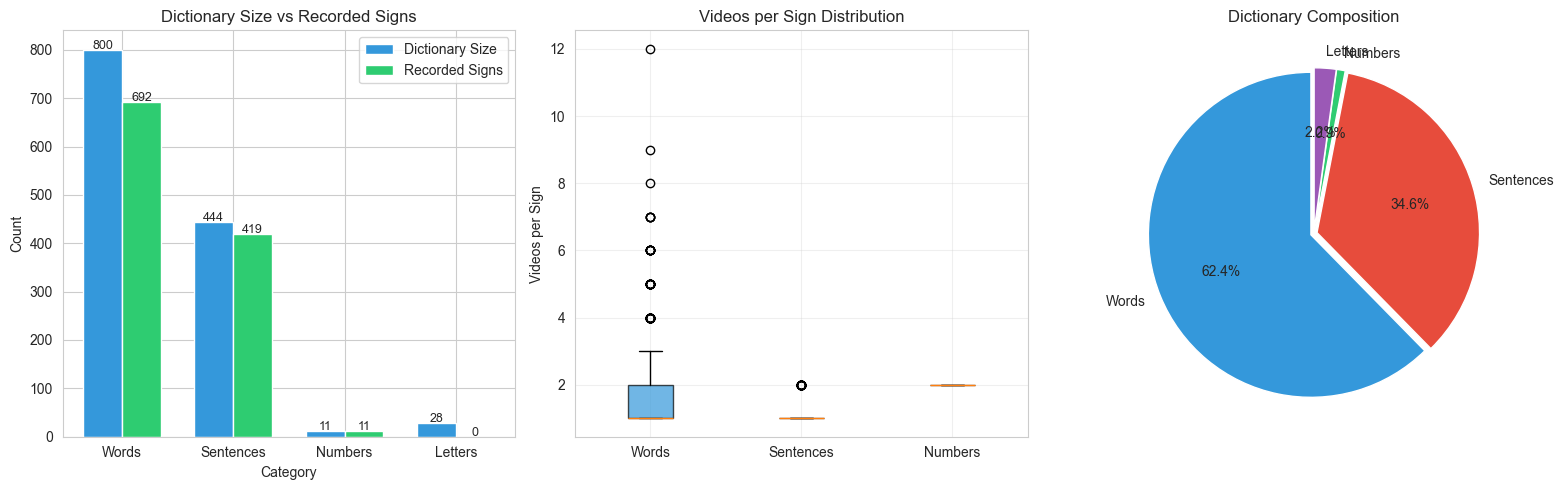


------------------------------------------------------------
VOCABULARY DETAILS BY CATEGORY
------------------------------------------------------------

WORDS:
  Total vocabulary size: 800
  Recorded unique signs: 692

  Most recorded signs (top 5):
    ID 34: "معلم" - 12 videos
    ID 344: "سيئ" - 9 videos
    ID 35: "طالب" - 8 videos
    ID 31: "مدرسة" - 7 videos
    ID 347: "ممكن" - 7 videos

  Least recorded signs (bottom 5):
    ID 525: "يصعد" - 1 videos
    ID 524: "ينزل" - 1 videos
    ID 523: "يشرب" - 1 videos
    ID 522: "يأكل" - 1 videos
    ID 801: "Unknown" - 1 videos

SENTENCES:
  Total vocabulary size: 444
  Recorded unique signs: 419

  Most recorded signs (top 5):
    ID 213: "الشارع مزدحم اليوم" - 2 videos
    ID 32: "أدرس في الجامعة" - 2 videos
    ID 202: "اشتريت بعض الأشياء من البقالة" - 2 videos
    ID 201: "ذهبت إلى السوق اليوم" - 2 videos
    ID 200: "التصوير مسموح" - 2 videos

  Least recorded signs (bottom 5):
    ID 139: "أكلت الغداء مع عائلتي" - 1 videos
  

In [38]:
# Dictionary Size Analysis
print('=' * 80)
print('DICTIONARY SIZE ANALYSIS')
print('=' * 80)

# Analyze vocabulary/dictionary for each category
dict_stats = []

for category in ['Words', 'Sentences', 'Numbers', 'Letters']:
    label_dict = labels.get(category, {})
    df = video_data.get(category, pd.DataFrame())
    
    # Dictionary size from labels file
    total_labels = len(label_dict)
    
    # Recorded unique signs
    recorded_unique = df['item_id'].nunique() if len(df) > 0 else 0
    
    # Videos per sign statistics
    if len(df) > 0:
        videos_per_sign = df.groupby('item_id').size()
        min_videos = videos_per_sign.min()
        max_videos = videos_per_sign.max()
        mean_videos = videos_per_sign.mean()
        std_videos = videos_per_sign.std()
    else:
        min_videos = max_videos = mean_videos = std_videos = 0
    
    dict_stats.append({
        'Category': category,
        'Dictionary Size': total_labels,
        'Recorded Signs': recorded_unique,
        'Coverage %': round(recorded_unique / total_labels * 100, 1) if total_labels > 0 else 0,
        'Total Videos': len(df),
        'Min Videos/Sign': min_videos,
        'Max Videos/Sign': max_videos,
        'Avg Videos/Sign': round(mean_videos, 2),
        'Std Videos/Sign': round(std_videos, 2) if not np.isnan(std_videos) else 0
    })

dict_df = pd.DataFrame(dict_stats)
display(dict_df)

# Visualization of dictionary sizes
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Dictionary size comparison
ax1 = axes[0]
x = np.arange(len(dict_df))
width = 0.35
bars1 = ax1.bar(x - width/2, dict_df['Dictionary Size'], width, label='Dictionary Size', color='#3498db')
bars2 = ax1.bar(x + width/2, dict_df['Recorded Signs'], width, label='Recorded Signs', color='#2ecc71')
ax1.set_xlabel('Category')
ax1.set_ylabel('Count')
ax1.set_title('Dictionary Size vs Recorded Signs')
ax1.set_xticks(x)
ax1.set_xticklabels(dict_df['Category'])
ax1.legend()
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             int(bar.get_height()), ha='center', fontsize=9)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             int(bar.get_height()), ha='center', fontsize=9)

# Plot 2: Videos per sign distribution
ax2 = axes[1]
all_videos_per_sign = []
category_labels = []
for category in ['Words', 'Sentences', 'Numbers', 'Letters']:
    df = video_data.get(category, pd.DataFrame())
    if len(df) > 0:
        vps = df.groupby('item_id').size().values
        all_videos_per_sign.append(vps)
        category_labels.append(category)

if all_videos_per_sign:
    bp = ax2.boxplot(all_videos_per_sign, labels=category_labels, patch_artist=True)
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
    for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
ax2.set_ylabel('Videos per Sign')
ax2.set_title('Videos per Sign Distribution')
ax2.grid(True, alpha=0.3)

# Plot 3: Pie chart of total dictionary composition
ax3 = axes[2]
sizes = dict_df['Dictionary Size'].values
labels_pie = dict_df['Category'].values
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
explode = (0.02, 0.02, 0.02, 0.02)
ax3.pie(sizes, explode=explode, labels=labels_pie, colors=colors, autopct='%1.1f%%',
        shadow=False, startangle=90)
ax3.set_title('Dictionary Composition')

plt.tight_layout()
plt.show()

# Detailed breakdown
print('\n' + '-' * 60)
print('VOCABULARY DETAILS BY CATEGORY')
print('-' * 60)

for category in ['Words', 'Sentences']:
    label_dict = labels.get(category, {})
    df = video_data.get(category, pd.DataFrame())
    
    print(f'\n{category.upper()}:')
    print(f'  Total vocabulary size: {len(label_dict)}')
    
    if len(df) > 0:
        # Sample of recorded items
        print(f'  Recorded unique signs: {df["item_id"].nunique()}')
        
        # Most and least recorded signs
        videos_per_sign = df.groupby('item_id').size().sort_values(ascending=False)
        
        print(f'\n  Most recorded signs (top 5):')
        for item_id, count in videos_per_sign.head(5).items():
            label_text = label_dict.get(item_id, 'Unknown')
            print(f'    ID {item_id}: "{label_text}" - {count} videos')
        
        print(f'\n  Least recorded signs (bottom 5):')
        for item_id, count in videos_per_sign.tail(5).items():
            label_text = label_dict.get(item_id, 'Unknown')
            print(f'    ID {item_id}: "{label_text}" - {count} videos')

# Summary statistics
print('\n' + '=' * 60)
print('TOTAL DICTIONARY SUMMARY')
print('=' * 60)
total_dict_size = dict_df['Dictionary Size'].sum()
total_recorded = dict_df['Recorded Signs'].sum()
total_videos = dict_df['Total Videos'].sum()
print(f'Total signs in dictionary: {total_dict_size}')
print(f'Total unique signs recorded: {total_recorded}')
print(f'Overall coverage: {total_recorded/total_dict_size*100:.1f}%')
print(f'Total video recordings: {total_videos}')

## 14. Inter-Annotator Agreement Analysis
Analysis of consistency between different signers (annotators) recording the same signs.
This section examines agreement in signing duration and coverage patterns across annotators.

INTER-ANNOTATOR (SIGNER) AGREEMENT ANALYSIS

WORDS:
--------------------------------------------------
  Signers: 8 (S01, S02, S03, S04, S05, S06, S07, S09)
  Signs with multiple signers: 143 / 692
  Duration Coefficient of Variation (CV):
    Mean CV: 0.331 (lower = more agreement)
    Min CV: 0.000, Max CV: 0.791
    Agreement Level: Low

SENTENCES:
--------------------------------------------------
  Signers: 8 (S01, S02, S03, S04, S06, S07, S08, S09)
  Signs with multiple signers: 5 / 419
  Duration Coefficient of Variation (CV):
    Mean CV: 0.125 (lower = more agreement)
    Min CV: 0.026, Max CV: 0.209
    Agreement Level: Good


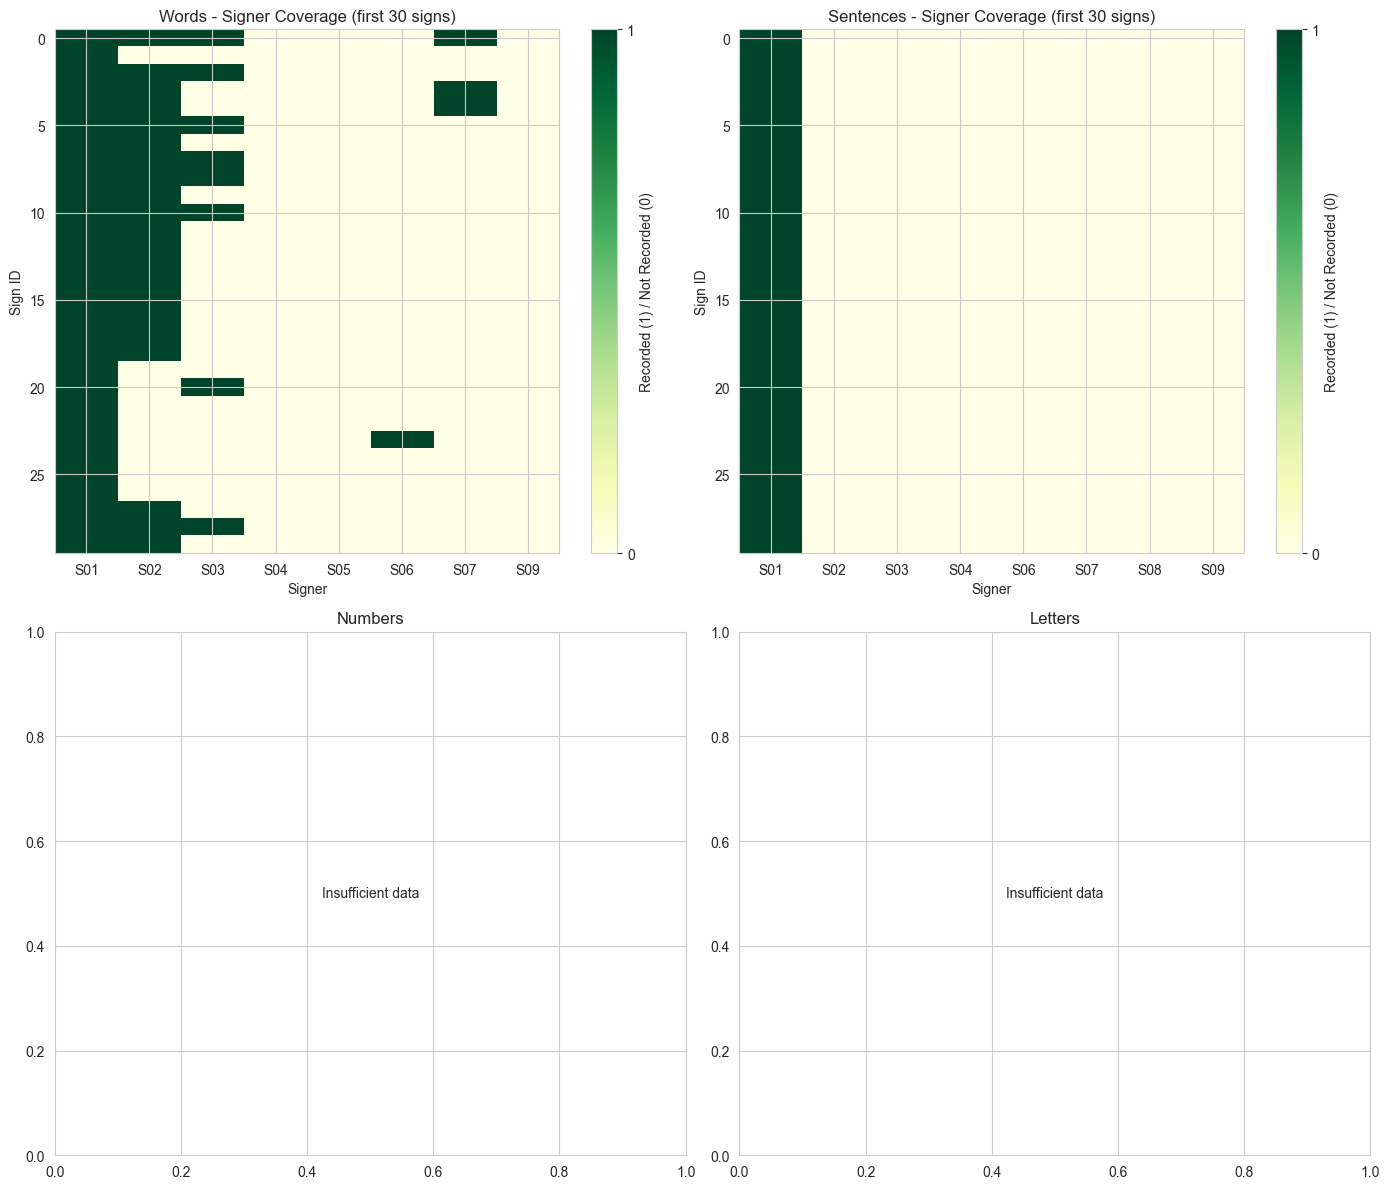


PAIRWISE SIGNER AGREEMENT (Duration Correlation)

WORDS - Pearson Correlation between signers:
  S01 vs S02: r = 0.383 (p = 0.0055, n = 51)
  S01 vs S03: r = 0.554 (p = 0.0259, n = 16)
  S01 vs S06: r = -0.279 (p = 0.2091, n = 22)
  S01 vs S07: r = -0.145 (p = 0.5103, n = 23)
  S02 vs S03: r = 0.257 (p = 0.3555, n = 15)
  S02 vs S06: r = 0.570 (p = 0.1398, n = 8)
  S02 vs S07: r = 0.661 (p = 0.0374, n = 10)
  S03 vs S06: r = 0.713 (p = 0.0000, n = 29)
  S03 vs S07: r = -0.179 (p = 0.3438, n = 30)
  S04 vs S07: r = -0.185 (p = 0.8147, n = 4)
  S06 vs S07: r = 0.841 (p = 0.3639, n = 3)

SENTENCES - Pearson Correlation between signers:
  S03 vs S06: r = 0.839 (p = 0.1614, n = 4)


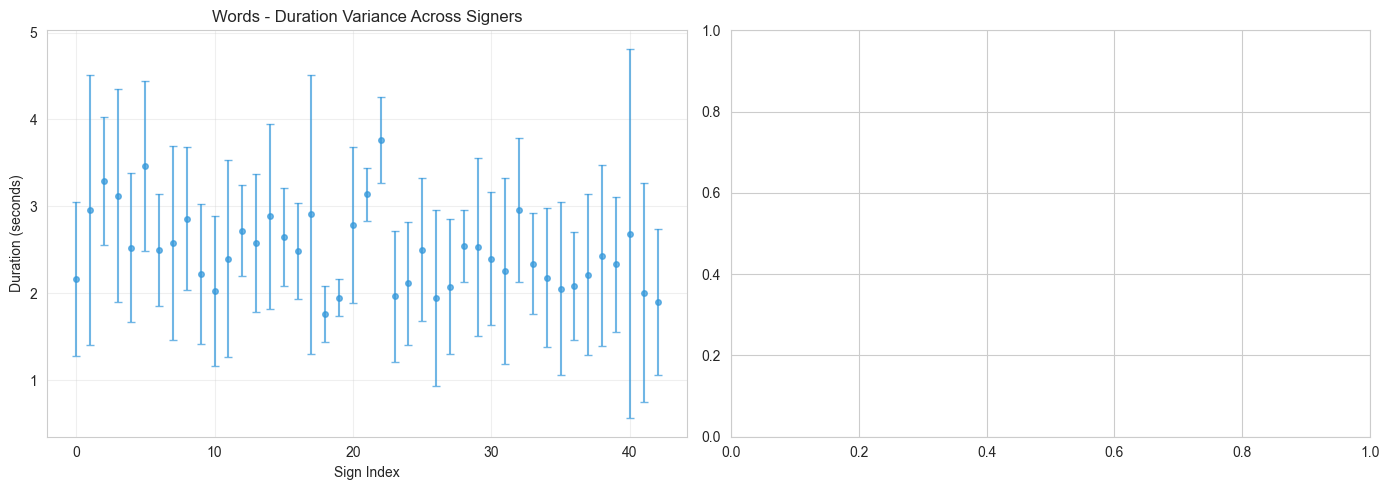


INTER-ANNOTATOR AGREEMENT SUMMARY


,Category,Signers,Signs,Coverage %,Signs with 2+ Signers,Mean Duration CV,Agreement Level
0,Words,8,692,15.8,143,0.331,Low
1,Sentences,8,419,12.6,5,0.125,Good


In [39]:
# Inter-Annotator (Signer) Agreement Analysis
from scipy import stats
from itertools import combinations

print('=' * 80)
print('INTER-ANNOTATOR (SIGNER) AGREEMENT ANALYSIS')
print('=' * 80)

def compute_icc(data_matrix):
    """
    Compute Intraclass Correlation Coefficient (ICC) for agreement analysis.
    Uses ICC(2,1) - two-way random effects, absolute agreement, single rater.
    """
    n_subjects, n_raters = data_matrix.shape
    
    # Remove subjects with missing data
    valid_mask = ~np.any(np.isnan(data_matrix), axis=1)
    data = data_matrix[valid_mask]
    
    if len(data) < 2:
        return np.nan
    
    n = len(data)
    k = data.shape[1]
    
    # Grand mean
    grand_mean = np.mean(data)
    
    # Subject means
    subject_means = np.mean(data, axis=1)
    
    # Rater means
    rater_means = np.mean(data, axis=0)
    
    # Sum of squares
    SS_total = np.sum((data - grand_mean) ** 2)
    SS_between_subjects = k * np.sum((subject_means - grand_mean) ** 2)
    SS_between_raters = n * np.sum((rater_means - grand_mean) ** 2)
    SS_residual = SS_total - SS_between_subjects - SS_between_raters
    
    # Mean squares
    MS_between_subjects = SS_between_subjects / (n - 1) if n > 1 else 0
    MS_between_raters = SS_between_raters / (k - 1) if k > 1 else 0
    MS_residual = SS_residual / ((n - 1) * (k - 1)) if (n - 1) * (k - 1) > 0 else 0
    
    # ICC(2,1)
    icc = (MS_between_subjects - MS_residual) / (MS_between_subjects + (k - 1) * MS_residual + 
           (k / n) * (MS_between_raters - MS_residual)) if MS_between_subjects > 0 else 0
    
    return max(0, min(1, icc))  # Bound between 0 and 1

def analyze_signer_agreement(df, category):
    """Analyze agreement between signers for a category."""
    if len(df) == 0 or 'speaker' not in df.columns or 'duration_sec' not in df.columns:
        return None
    
    # Get unique speakers
    speakers = sorted(df['speaker'].unique())
    
    if len(speakers) < 2:
        return None
    
    # Create a matrix of durations: rows = signs, columns = speakers
    signs = sorted(df['item_id'].unique())
    
    # Average duration per sign per speaker
    pivot = df.groupby(['item_id', 'speaker'])['duration_sec'].mean().unstack(fill_value=np.nan)
    
    return {
        'speakers': speakers,
        'signs': signs,
        'pivot': pivot,
        'n_signs': len(signs),
        'n_speakers': len(speakers)
    }

# Analyze each category
agreement_results = {}

for category in ['Words', 'Sentences', 'Numbers', 'Letters']:
    df = video_data.get(category, pd.DataFrame())
    result = analyze_signer_agreement(df, category)
    
    if result is not None:
        agreement_results[category] = result
        
        print(f'\n{category.upper()}:')
        print('-' * 50)
        print(f'  Signers: {len(result["speakers"])} ({", ".join(result["speakers"])})')
        print(f'  Signs with multiple signers: ', end='')
        
        # Count signs recorded by multiple signers
        multi_signer_signs = (result['pivot'].notna().sum(axis=1) > 1).sum()
        print(f'{multi_signer_signs} / {result["n_signs"]}')
        
        # Compute duration agreement statistics
        pivot = result['pivot']
        
        # For signs with at least 2 signers, compute coefficient of variation
        cv_values = []
        for sign_id in pivot.index:
            row = pivot.loc[sign_id].dropna()
            if len(row) >= 2:
                cv = row.std() / row.mean() if row.mean() > 0 else 0
                cv_values.append(cv)
        
        if cv_values:
            mean_cv = np.mean(cv_values)
            print(f'  Duration Coefficient of Variation (CV):')
            print(f'    Mean CV: {mean_cv:.3f} (lower = more agreement)')
            print(f'    Min CV: {min(cv_values):.3f}, Max CV: {max(cv_values):.3f}')
            
            # Interpret CV
            if mean_cv < 0.1:
                agreement_level = 'Excellent'
            elif mean_cv < 0.2:
                agreement_level = 'Good'
            elif mean_cv < 0.3:
                agreement_level = 'Moderate'
            else:
                agreement_level = 'Low'
            print(f'    Agreement Level: {agreement_level}')

# Visualization of signer agreement
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, category in enumerate(['Words', 'Sentences', 'Numbers', 'Letters']):
    ax = axes[idx]
    
    if category not in agreement_results:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{category}')
        continue
    
    result = agreement_results[category]
    pivot = result['pivot']
    
    # Heatmap of coverage (which signer recorded which sign)
    coverage_matrix = pivot.notna().astype(int)
    
    # Select subset if too many signs
    if len(coverage_matrix) > 30:
        coverage_matrix = coverage_matrix.iloc[:30]
    
    # Create heatmap
    im = ax.imshow(coverage_matrix.values, aspect='auto', cmap='YlGn')
    ax.set_xlabel('Signer')
    ax.set_ylabel('Sign ID')
    ax.set_title(f'{category} - Signer Coverage (first 30 signs)')
    ax.set_xticks(range(len(coverage_matrix.columns)))
    ax.set_xticklabels(coverage_matrix.columns)
    
    # Add colorbar
    plt.colorbar(im, ax=ax, label='Recorded (1) / Not Recorded (0)', ticks=[0, 1])

plt.tight_layout()
plt.show()

# Pairwise signer agreement analysis
print('\n' + '=' * 80)
print('PAIRWISE SIGNER AGREEMENT (Duration Correlation)')
print('=' * 80)

for category in ['Words', 'Sentences']:
    if category not in agreement_results:
        continue
    
    result = agreement_results[category]
    pivot = result['pivot']
    speakers = result['speakers']
    
    print(f'\n{category.upper()} - Pearson Correlation between signers:')
    
    # Compute pairwise correlations
    correlation_matrix = []
    for s1, s2 in combinations(speakers, 2):
        if s1 in pivot.columns and s2 in pivot.columns:
            common = pivot[[s1, s2]].dropna()
            if len(common) >= 3:
                corr, pval = stats.pearsonr(common[s1], common[s2])
                print(f'  {s1} vs {s2}: r = {corr:.3f} (p = {pval:.4f}, n = {len(common)})')

# Agreement visualization - Duration comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, category in enumerate(['Words', 'Sentences']):
    ax = axes[idx]
    
    if category not in agreement_results:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{category}')
        continue
    
    result = agreement_results[category]
    pivot = result['pivot']
    
    # For each sign, plot the duration range across signers
    sign_ids = []
    means = []
    stds = []
    
    for sign_id in sorted(pivot.index)[:50]:  # First 50 signs
        row = pivot.loc[sign_id].dropna()
        if len(row) >= 2:
            sign_ids.append(sign_id)
            means.append(row.mean())
            stds.append(row.std())
    
    if sign_ids:
        x = range(len(sign_ids))
        ax.errorbar(x, means, yerr=stds, fmt='o', capsize=3, capthick=1, 
                   markersize=4, alpha=0.7, color='#3498db')
        ax.set_xlabel('Sign Index')
        ax.set_ylabel('Duration (seconds)')
        ax.set_title(f'{category} - Duration Variance Across Signers')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table of inter-annotator agreement
print('\n' + '=' * 80)
print('INTER-ANNOTATOR AGREEMENT SUMMARY')
print('=' * 80)

summary_agreement = []
for category in ['Words', 'Sentences', 'Numbers', 'Letters']:
    if category not in agreement_results:
        continue
    
    result = agreement_results[category]
    pivot = result['pivot']
    
    # Coverage statistics
    coverage = pivot.notna()
    total_possible = len(pivot) * len(pivot.columns)
    actual_recordings = coverage.sum().sum()
    
    # CV calculation
    cv_values = []
    for sign_id in pivot.index:
        row = pivot.loc[sign_id].dropna()
        if len(row) >= 2:
            cv = row.std() / row.mean() if row.mean() > 0 else 0
            cv_values.append(cv)
    
    summary_agreement.append({
        'Category': category,
        'Signers': len(result['speakers']),
        'Signs': len(pivot),
        'Coverage %': round(actual_recordings / total_possible * 100, 1),
        'Signs with 2+ Signers': (coverage.sum(axis=1) >= 2).sum(),
        'Mean Duration CV': round(np.mean(cv_values), 3) if cv_values else np.nan,
        'Agreement Level': 'Excellent' if np.mean(cv_values) < 0.1 else 
                          'Good' if np.mean(cv_values) < 0.2 else 
                          'Moderate' if np.mean(cv_values) < 0.3 else 'Low' if cv_values else 'N/A'
    })

if summary_agreement:
    summary_df = pd.DataFrame(summary_agreement)
    display(summary_df)